In [1]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_VISIBLE_DEVICES=0


In [2]:
from time_distance.src.nako import NakoDataset, get_nako_paths
from time_distance.src.nako import IMAGE_TYPES
from time_distance.src.load_data import load_areds, load_nako, load_new_nako
from time_distance.src.dataset import AREDSVanillaDataset, load_datasets, NAKONewDataset, AREDSDownStreamDataset


In [3]:
image_size = 224
image_dir = get_nako_paths(dataset='590', img_res=str(image_size))

In [38]:
import torchvision.transforms as transforms

augment_train = transforms.Compose([transforms.ToTensor(),
                                         transforms.Resize(image_size), 
                                        #  transforms.RandomResizedCrop(image_size, scale=(0.2, 1.0)),  
                                        transforms.RandomHorizontalFlip(),
                                        #  transforms.RandomGrayscale(p=0.2),
                                        transforms.Normalize(mean=[0.419, 0.209, 0.122],
                                                             std = [0.270, 0.157, 0.105] )
                                        # transforms.Normalize(mean = [0.417, 0.201, 0.114],
                                        #                      std =  [0.265, 0.140, 0.090])
                                         
                                         ])

In [40]:
label_name = 'basis_uort'
return_ids = False
dataset_train = NakoDataset(image_dir, IMAGE_TYPES, transform=augment_train, split='train', return_ids=return_ids, feature_name=label_name)


In [41]:
dataset_train[0][0].min(), dataset_train[0][0].max()

(tensor(-1.5519), tensor(4.8512))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5518517..4.8511677].


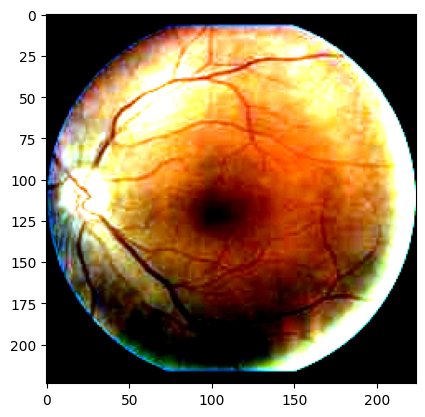

In [42]:
import matplotlib.pyplot as plt
plt.imshow(dataset_train[0][0].permute(1,2,0))
plt.show()

In [43]:
img = dataset_train[0][0]
print(img.min(), img.max(), img.mean(), img.std())


tensor(-1.5519) tensor(4.8512) tensor(0.1083) tensor(0.9446)


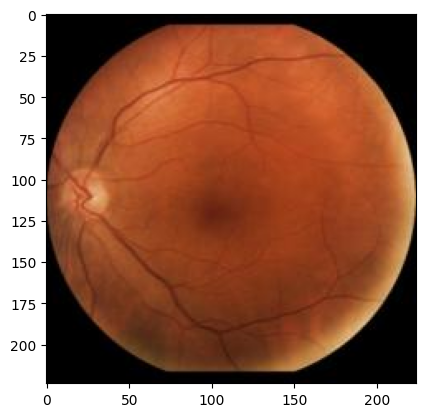

In [20]:
import matplotlib.pyplot as plt
plt.imshow(dataset_train[0][0].permute(1,2,0))
plt.show()

In [3]:
dataset_str = 'areds'
cloud = 'cin'
train_ssl, df_train, val, test, image_folder = load_datasets(dataset_str, cloud=cloud) 

In [4]:
train_ssl.shape

(6170, 38)

In [6]:
import pandas as pd
df = pd.concat([df_train, val, test])
print(df.shape)
df.head()

(133293, 38)


,patient_id,eye_id,original_image_name,original_img_size,new_image_name,new_image_size,KeyError,Gradable,Confidence,patient_idright,...,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,equal,index,converters,first_visit,len_images
0,3438,3438_right,/gpfs01/berens/data/data/areds//images-f2-1024...,"(1513, 1024)",C_57214/57214_04_F2_RE_LS.jpg,"(198, 198)",OK,Ungradeable,0.049025,57214,...,N,N,6.0,Y,77.1,False,8588,0,77.1,22
1,3438,3438_right,/gpfs01/berens/data/data/areds//images-f2-1024...,"(1513, 1024)",C_57214/57214_04_F2_RE_RS.jpg,"(198, 198)",OK,Ungradeable,0.052885,57214,...,N,N,6.0,Y,77.1,False,8587,0,77.1,22
2,3438,3438_right,/gpfs01/berens/data/data/areds//images-f2-1024...,"(1513, 1024)",C_57214/57214_06_F2_RE_LS.jpg,"(198, 198)",OK,Ungradeable,0.06659,57214,...,N,N,6.0,Y,78.1,False,8599,0,77.1,22
3,3438,3438_right,/gpfs01/berens/data/data/areds//images-f2-1024...,"(1513, 1024)",C_57214/57214_06_F2_RE_RS.jpg,"(198, 198)",OK,Ungradeable,0.077538,57214,...,N,N,6.0,Y,78.1,False,8604,0,77.1,22
4,3438,3438_right,/gpfs01/berens/data/data/areds//images-f2-1024...,"(1513, 1024)",C_57214/57214_08_F2_RE_LS.jpg,"(198, 198)",OK,Ungradeable,0.031783,57214,...,N,N,6.0,Y,79.1,False,8573,0,77.1,22


In [8]:
len(df['patient_id'].value_counts())

4443

In [9]:
df.columns

Index(['patient_id', 'eye_id', 'original_image_name', 'original_img_size',
       'new_image_name', 'new_image_size', 'KeyError', 'Gradable',
       'Confidence', 'patient_idright', 'image_file', 'patient_idleft',
       'image_id', 'visit_number', 'image_eye', 'image_field', 'image_side',
       'image_path', 'diagnosis_amd_grade', 'diagnosis_amd_grade_other_eye',
       'clinical_smoking_status', 'clinical_bmi_status',
       'clinical_diabetes_status', 'patient_sex',
       'clinical_high_blood_pressure_baseline',
       'clinical_visual_acuity_baseline_right',
       'clinical_visual_acuity_baseline_left', 'clinical_treatment_category',
       'clinical_laser_photocoagulation_right',
       'clinical_laser_photocoagulation_left', 'diagnosis_final_amd_status',
       'clinical_centrum_intake', 'patient_age', 'equal', 'index',
       'converters', 'first_visit', 'len_images'],
      dtype='object')

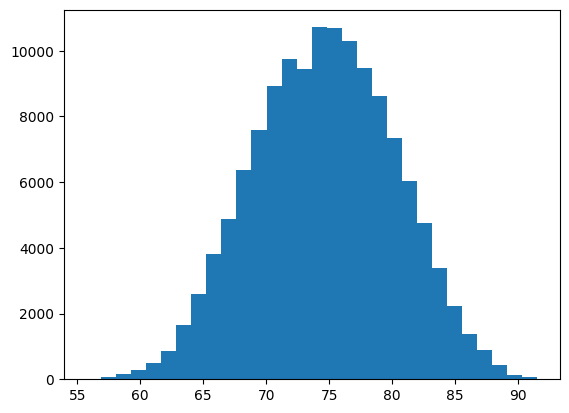

In [13]:
import matplotlib.pyplot as plt
plt.hist(df['patient_age'], bins=30)
plt.show()

In [3]:
img_size = 224
batch_size = 1
ssl_method = ''
cloud = 'cin'
label_type = 'converters'
task = 'classification'
from torchvision import transforms

areds_transform_train =areds_transform_val = transforms.Compose([

            transforms.Resize(img_size),
            
            ])

In [4]:
dataset_train, dataset_test, dataset_val, transforms_ = load_areds( 
                            image_size = img_size, 
                            batch_size = batch_size, 
                            ssl_method = ssl_method,
                            return_loader=False,
                            normalize= True,
                            return_all = False,
                            augment_train =  areds_transform_train,
                            augment_test=areds_transform_val,
                            augment_val=areds_transform_val, 
                            cloud = cloud,
                            label_type= label_type,
                            task = task
                                        )


 
 *** Loading areds dataset from cloud cin with label type converters *** 
 

len of directory 5023 train shape (92582, 38) val shape (8188, 38) test shape (32523, 38)

 
 using downstream dataset 
 
 


In [24]:
from time_distance.src.dataset import load_datasets

In [ ]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import random
import os
def display_areds(train, image_folder, prefix='', n_samples = 5, n_images_per_id = 5):
    images_to_view = {}
    random_ids = random.sample(list(range(train.shape[0])), n_samples)
    print(random_ids)
    for i in random_ids:
        for m in range(2):
            row = train.iloc[i]
            id = row['eye_id']
            image_list = row['image_path']
            len_images = min(10, len(image_list))
            for j in range(len_images):
                image_name = image_list[j]
                label = row['diagnosis_amd_grade'][j]
                image_eye = row['image_eye'][j]
                visit_number = row['visit_number'][j]
                image_side = row['image_side'][j]
                image  = Image.open(os.path.join( image_folder, f"{prefix}{image_name}")).convert("RGB")

                if id not in images_to_view:
                    images_to_view[id] = {'images': [], 'visit_number': [], 'image_eye': [], 'label': [], 'image_side': []}
                if len(images_to_view[id]['images']) < n_images_per_id:
                    images_to_view[id]['images'].append(image)
                    images_to_view[id]['visit_number'].append(visit_number)
                    images_to_view[id]['image_eye'].append(image_eye)
                    images_to_view[id]['label'].append(label)
                    images_to_view[id]['image_side'].append(image_side)



    fig, axs = plt.subplots( n_samples, n_images_per_id+1, figsize=(n_images_per_id * 2, 3))
    for t, (id, data) in enumerate(images_to_view.items()):
        axs[t, 0].text(0,0.3, id)
        axs[t, 0].axis('off')
        n_images_in_id = len(data['images'])
        
        for k in range(n_images_in_id): 
            
            image = data['images'][k] 
            image_eye = data['image_eye'][k]
            amount_ = data['visit_number'][k]
            label = data["label"][k]
            image_side = data["image_side"][k]

            image_arr = np.array(image)
            
            title = f"{image_eye} {image_side} V_no: {amount_} AMD: {label}"
            axs[t, k+1].imshow(image_arr)
            axs[t, k+1].set_title(title, fontsize = 6)
        
            axs[t, k+1].axis('off')
    
    # return images_to_view


In [27]:
load_datasets('cin')

ValueError('*****cin does not exist! Specify the type of data*****')

In [39]:
train[train['eye_id'] =='5167_right']

,eye_id,patient_id,original_image_name,original_img_size,new_image_name,new_image_size,KeyError,Gradable,Confidence,patient_idright,...,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,equal,index,converters,first_visit,len_images
2494,5167_right,"[5167, 5167, 5167, 5167, 5167, 5167, 5167, 516...",[/gpfs01/berens/data/data/areds//images-f2-102...,"[(1513, 1024), (1513, 1024), (1513, 1024), (15...","[C_61517/61517_02_F2_RE_LS.jpg, C_61517/61517_...","[(198, 198), (198, 198), (198, 198), (198, 198...","[OK, OK, OK, OK, OK, OK, OK, OK, OK, OK, OK, OK]","[Ungradeable, Ungradeable, Ungradeable, Ungrad...","[0.029554006, 0.029702395, 0.02202338, 0.03250...","[61517, 61517, 61517, 61517, 61517, 61517, 615...",...,"[Y, Y, Y, Y, Y, Y, Y, Y, Y, Y, Y, Y]","[N, N, N, N, N, N, N, N, N, N, N, N]","[11.0, 11.0, 11.0, 11.0, 11.0, 11.0, 11.0, 11....","[Y, Y, Y, Y, Y, Y, Y, Y, Y, Y, Y, Y]","[64.4, 64.4, 65.2, 65.2, 66.3, 66.3, 67.3, 67....","[False, False, False, False, False, False, Fal...","[7957, 7967, 7970, 7963, 7975, 7959, 7977, 797...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[64.4, 64.4, 64.4, 64.4, 64.4, 64.4, 64.4, 64....",12


In [76]:
train, vanilla_train, val, test,  image_folder = load_datasets('areds',cloud)


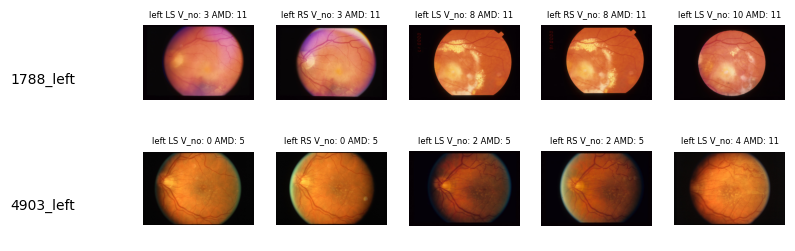

In [ ]:
display_areds(train, image_folder, prefix='', n_samples = 2, n_images_per_id = 5)

In [77]:
import pandas as pd
all_df = pd.concat([vanilla_train, test, val], axis = 0)

converters_count = all_df['converters'].value_counts()
converters_count

converters
0    111591
1     21702
Name: count, dtype: int64

In [78]:
all_df.columns

Index(['patient_id', 'eye_id', 'original_image_name', 'original_img_size',
       'new_image_name', 'new_image_size', 'KeyError', 'Gradable',
       'Confidence', 'patient_idright', 'image_file', 'patient_idleft',
       'image_id', 'visit_number', 'image_eye', 'image_field', 'image_side',
       'image_path', 'diagnosis_amd_grade', 'diagnosis_amd_grade_other_eye',
       'clinical_smoking_status', 'clinical_bmi_status',
       'clinical_diabetes_status', 'patient_sex',
       'clinical_high_blood_pressure_baseline',
       'clinical_visual_acuity_baseline_right',
       'clinical_visual_acuity_baseline_left', 'clinical_treatment_category',
       'clinical_laser_photocoagulation_right',
       'clinical_laser_photocoagulation_left', 'diagnosis_final_amd_status',
       'clinical_centrum_intake', 'patient_age', 'equal', 'index',
       'converters', 'first_visit', 'len_images'],
      dtype='object')

In [79]:
all_df = all_df.sort_values(by=['eye_id', 'visit_number'])

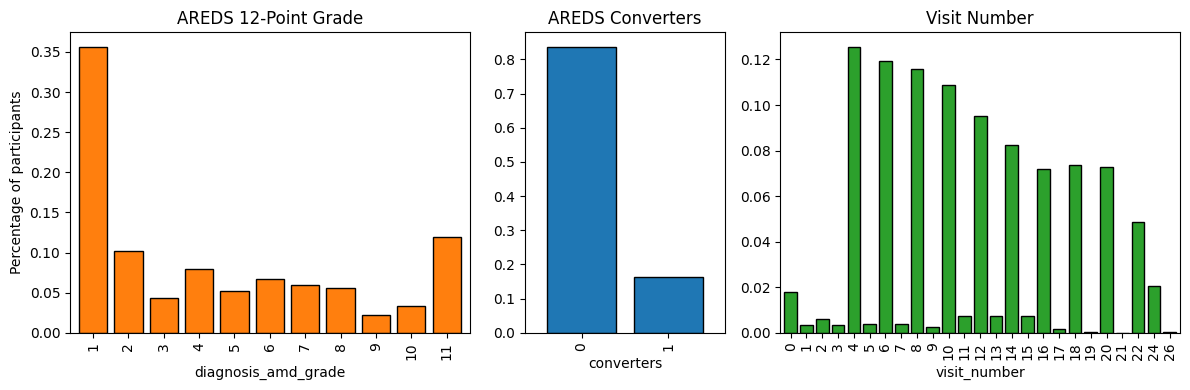

In [81]:
colors = plt.rcParams["axes.prop_cycle"]()

fig = plt.figure(figsize=(12, 4))

gs = fig.add_gridspec(
    1, 3,
    width_ratios=[1, 0.5, 1]   # make ax[1] half the width
)

ax = [
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
]

converters_count = all_df['converters'].value_counts(normalize=True) 

converters_count.plot(kind='bar', ax=ax[1],  width=0.8,  color=next(colors)["color"], edgecolor='black', rot=90,)

all_count = all_df['diagnosis_amd_grade'].value_counts(normalize=True) 
labels_order = list(range(1, 12))   # extend as needed
all_count = all_count.reindex(labels_order)
all_count.plot(kind='bar', ax=ax[0] ,  width=0.8,  color=next(colors)["color"], edgecolor='black', rot=90,)

vist_number = all_df['visit_number'].value_counts(normalize=True) 
vist_number = vist_number.sort_index()
vist_number.plot(kind='bar', ax=ax[2],  width=0.8,  color=next(colors)["color"] , edgecolor='black', rot=90,)

ax[0].set_ylabel('Percentage of participants')

ax[1].set_title('AREDS Converters')
ax[0].set_title('AREDS 12-Point Grade')
ax[2].set_title('Visit Number')
plt.tight_layout()
plt.show()

## Loading

In [2]:
from nako_pretrain_simclr import LOWRES_IMAGES_DIR, NakoImageDataset, load_nako
import pandas as pd
import os


ImportError: cannot import name 'load_nako' from 'nako_pretrain_simclr' (/gpfs01/berens/user/inwabufo/time_distance/time_distance/t_cross_long/nako_pretrain_simclr.py)

In [3]:
img_size = 224
batch_size = 1
ssl_method = ''
size = (img_size, img_size)
image_dir = os.path.join(LOWRES_IMAGES_DIR, str(512), 'rt_leftcentral_1') # Only for nako


In [4]:
from torchvision import transforms


In [ ]:
dataset_train = NakoImageDataset(image_dir, train, y_train)
contrastive_dataset = SSLDataset(dataset=dataset_train, transform=augment_train, ssl_model = ssl_method)
train_loader = DataLoader(contrastive_dataset, batch_size = batch_size, num_workers = 20, shuffle= True)
transforms_ = f"{aug2string(augment_train)}" 

In [3]:
IMAGES_DIR = '/gpfs01/berens/data/data/NAKO/nako_decrypted/images/NAKO-590_Retina'
LABELS_DIR = '/gpfs01/berens/data/data/NAKO/nako_decrypted/labels/NAKO-590_22032024'
METADATA_FILE = 'NAKO-590_export_baseline_Metadaten.csv'

In [3]:
root = '/gpfs01/berens/user/inwabufo/time_distance/time_distance/datasets'
image_folder = f'{root}/AREDS_macula'
train_ssl=pd.read_pickle(f'{root}/AREDS_macula_metadata/train_ssl.pkl')
vanilla_train = pd.read_pickle(f'{root}/AREDS_macula_metadata/train_vanilla.pkl')
test = pd.read_pickle(f'{root}/AREDS_macula_metadata/test.pkl')
val = pd.read_pickle(f'{root}/AREDS_macula_metadata/val.pkl')


In [4]:
train_ssl.shape, vanilla_train.shape, test.shape, val.shape

((6170, 38), (92582, 38), (32523, 38), (8188, 38))

In [5]:
vanilla_train.columns

Index(['patient_id', 'eye_id', 'original_image_name', 'original_img_size',
       'new_image_name', 'new_image_size', 'KeyError', 'Gradable',
       'Confidence', 'patient_idright', 'image_file', 'patient_idleft',
       'image_id', 'visit_number', 'image_eye', 'image_field', 'image_side',
       'image_path', 'diagnosis_amd_grade', 'diagnosis_amd_grade_other_eye',
       'clinical_smoking_status', 'clinical_bmi_status',
       'clinical_diabetes_status', 'patient_sex',
       'clinical_high_blood_pressure_baseline',
       'clinical_visual_acuity_baseline_right',
       'clinical_visual_acuity_baseline_left', 'clinical_treatment_category',
       'clinical_laser_photocoagulation_right',
       'clinical_laser_photocoagulation_left', 'diagnosis_final_amd_status',
       'clinical_centrum_intake', 'patient_age', 'equal', 'index',
       'converters', 'first_visit', 'len_images'],
      dtype='object')

In [6]:
vanilla_train['converters'].value_counts()

converters
0    77322
1    15260
Name: count, dtype: int64

In [7]:
vanilla_train['diagnosis_amd_grade'].value_counts()

diagnosis_amd_grade
1     32501
11    11039
2      9431
4      7216
6      6207
7      5664
8      5213
5      4905
3      4031
10     3366
9      2154
12      855
Name: count, dtype: int64

In [8]:
from torch.utils.data import Dataset
import os
from PIL import Image
import numpy as np
import torch
from torchvision import transforms  
import pandas as pd


In [9]:
class NAKONewDataset(Dataset):
    def __init__(
        self,
        image_dir,
        metadata_df,
        transform= None,
        **kwargs
    ) -> None:

        self.image_dir = image_dir
        self.metadata_df = metadata_df
        self.transform = transform       
        
    def __getitem__(self, idx: int):
        row= self.metadata_df.iloc[idx]
        
        image_path = row["new_image_name"]
        label = 0
        img_filename = os.path.join(self.image_dir, f"{image_path}")
        # print(patient_id, label, image_path)
        image = Image.open(img_filename).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)
        
        return image, label


    def __len__(self):
        return self.metadata_df.shape[0]
        

In [10]:
image_size = 224

In [21]:
augment_train = transforms.Compose([transforms.ToTensor(),
                                        #  transforms.Resize(image_size), 
                                        #  transforms.RandomResizedCrop(image_size, scale=(0.2, 1.0)),  
                                        # transforms.RandomHorizontalFlip(),
                                        #  transforms.RandomGrayscale(p=0.2),
                                        # transforms.Normalize(mean=[0.419, 0.209, 0.122],
                                        #                      std = [0.280, 0.164, 0.113] )
                                        # transforms.Normalize(mean = [0.417, 0.201, 0.114],
                                        #                      std =  [0.265, 0.140, 0.090])
                                         
                                         ])

In [6]:
import pandas as pd
root = '/gpfs01/berens/user/inwabufo/time_distance/time_distance/datasets'
image_folder = f'{root}/NAKO_macula'
all_data = f'{root}/nako_reports_macula_and_grade.csv'
vanilla_train = pd.read_csv(all_data)
train_ssl = vanilla_train
val = train_ssl
test = train_ssl
print(vanilla_train.shape)
vanilla_train.head()


(153134, 7)


,original_image_name,original_img_size,new_image_name,new_image_size,KeyError,Gradable,Confidence
0,/gpfs01/berens/data/data/NAKO/nako_decrypted/n...,"(512, 512)",C_rt_leftnasal/130822.jpg,"(256, 256)",OK,Ungradeable,0.118215
1,/gpfs01/berens/data/data/NAKO/nako_decrypted/n...,"(512, 512)",C_rt_leftnasal/113978.jpg,"(256, 256)",OK,Ungradeable,0.193996
2,/gpfs01/berens/data/data/NAKO/nako_decrypted/n...,"(512, 512)",C_rt_leftnasal/112480.jpg,"(256, 256)",OK,Gradeable,0.232728
3,/gpfs01/berens/data/data/NAKO/nako_decrypted/n...,"(512, 512)",C_rt_leftnasal/105569.jpg,"(256, 256)",OK,Ungradeable,0.135763
4,/gpfs01/berens/data/data/NAKO/nako_decrypted/n...,"(512, 512)",C_rt_leftnasal/137913.jpg,"(256, 256)",OK,Ungradeable,0.083499


In [7]:
vanilla_train.iloc[0, 0 ]

'/gpfs01/berens/data/data/NAKO/nako_decrypted/nako_lowres/512/rt_leftnasal/130822.jpg'

In [19]:
vanilla_train['image_id'] = vanilla_train['original_image_name'].apply(lambda x : x.split('/')[-1].split('.')[0])
vanilla_train['image_orient'] = vanilla_train['new_image_name'].apply(lambda x: x.split('/')[0].split('C_')[1])
df_grouped = vanilla_train.groupby(['image_id', 'image_orient'])['Confidence'].agg(list).reset_index()
df_grouped.shape

(153134, 3)

In [21]:
df_grouped

,image_id,image_orient,Confidence
0,100000,rt_leftcentral,[0.1884981]
1,100000,rt_leftnasal,[0.15141208]
2,100000,rt_rightcentral,[0.14005701]
3,100000,rt_rightnasal,[0.13337037]
4,100001,rt_leftcentral,[0.2532641]
...,...,...,...
153129,148461,rt_rightnasal,[0.042659607]
153130,148462,rt_leftcentral,[0.19337244]
153131,148462,rt_leftnasal,[0.106745996]
153132,148462,rt_rightcentral,[0.1281786]


In [20]:
vanilla_train['image_orient'].value_counts()

image_orient
rt_rightnasal      40526
rt_rightcentral    40248
rt_leftcentral     37158
rt_leftnasal       35202
Name: count, dtype: int64

In [22]:
len(set(vanilla_train['image_id']))

45247

In [ ]:
dataset_train = NAKONewDataset(image_folder, train_ssl, transform = augment_train)

torch.Size([3, 256, 256])


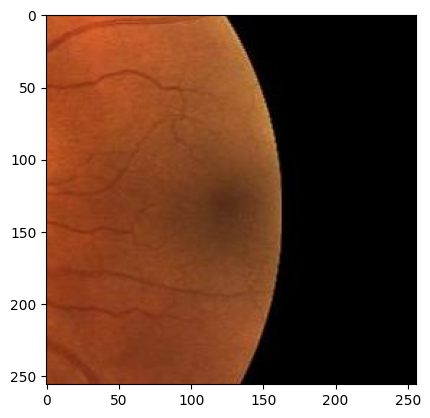

In [25]:
import matplotlib.pyplot as plt
img = dataset_train[5][0]
print(img.shape)
plt.imshow(img.permute(1, 2, 0))



In [5]:
image_size = 224
batch_size = 64

In [6]:
augment_train = transforms.Compose([
             transforms.RandomResizedCrop(size = image_size, scale=(0.2, 1.0)),  
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor()
])

In [15]:
dataset_train, dataset_test, dataset_val, transforms_ = load_areds(dataset_str = 'areds', 
                image_size = image_size, 
                batch_size = batch_size, 
                augment_train = augment_train,
                return_loader = False,
                cloud = 'macular',
                augment_test = None,
                contrastive = False,
                normalize = True,
                return_all = 'converters',
                prefix = 'C_'
                )

len of directory 5023 train shape (92582, 38) val shape (8188, 38) test shape (32523, 38)


In [ ]:
all_labels = []
for image, label in dataset_train:
    all_labels.append(label)

labels = np.array(all_labels)
print(labels.shape)
print(np.unique(labels, return_counts=True))

In [3]:
root = '/gpfs01/berens/user/inwabufo/time_distance/time_distance/datasets'
image_folder = f'{root}/AREDS_macula'
train_ssl=pd.read_pickle(f'{root}/AREDS_macula_metadata/train_ssl.pkl')
vanilla_train = pd.read_pickle(f'{root}/AREDS_macula_metadata/train_vanilla.pkl')
test = pd.read_pickle(f'{root}/AREDS_macula_metadata/test.pkl')
val = pd.read_pickle(f'{root}/AREDS_macula_metadata/val.pkl')

In [4]:
vanilla_train.head()

,patient_id,eye_id,original_image_name,original_img_size,new_image_name,new_image_size,KeyError,Gradable,Confidence,patient_idright,...,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,equal,index,converters,first_visit,len_images
0,3438,3438_right,/gpfs01/berens/data/data/areds//images-f2-1024...,"(1513, 1024)",C_57214/57214_04_F2_RE_LS.jpg,"(198, 198)",OK,Ungradeable,0.049025,57214,...,N,N,6.0,Y,77.1,False,8588,0,77.1,22
1,3438,3438_right,/gpfs01/berens/data/data/areds//images-f2-1024...,"(1513, 1024)",C_57214/57214_04_F2_RE_RS.jpg,"(198, 198)",OK,Ungradeable,0.052885,57214,...,N,N,6.0,Y,77.1,False,8587,0,77.1,22
2,3438,3438_right,/gpfs01/berens/data/data/areds//images-f2-1024...,"(1513, 1024)",C_57214/57214_06_F2_RE_LS.jpg,"(198, 198)",OK,Ungradeable,0.06659,57214,...,N,N,6.0,Y,78.1,False,8599,0,77.1,22
3,3438,3438_right,/gpfs01/berens/data/data/areds//images-f2-1024...,"(1513, 1024)",C_57214/57214_06_F2_RE_RS.jpg,"(198, 198)",OK,Ungradeable,0.077538,57214,...,N,N,6.0,Y,78.1,False,8604,0,77.1,22
4,3438,3438_right,/gpfs01/berens/data/data/areds//images-f2-1024...,"(1513, 1024)",C_57214/57214_08_F2_RE_LS.jpg,"(198, 198)",OK,Ungradeable,0.031783,57214,...,N,N,6.0,Y,79.1,False,8573,0,77.1,22


In [5]:
vanilla_train['converters'].value_counts()

converters
0    77322
1    15260
Name: count, dtype: int64

In [6]:
test['converters'].value_counts()

converters
0    27313
1     5210
Name: count, dtype: int64

In [7]:
val['converters'].value_counts()

converters
0    6956
1    1232
Name: count, dtype: int64

In [8]:
import matplotlib.pyplot as plt

In [10]:
all_df['converters']

0       0
1       0
2       0
3       0
4       0
       ..
8183    0
8184    0
8185    0
8186    0
8187    0
Name: converters, Length: 133293, dtype: object

In [ ]:
all_df = pd.concat([vanilla_train, test, val], axis = 0)

converters_count = all_df['converters'].value_counts()
converters_count

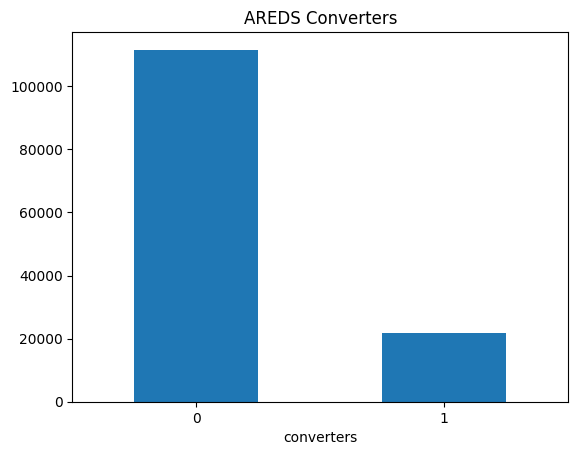

In [ ]:
converters_count.plot(kind='bar')
plt.title('AREDS Converters')
plt.xticks(rotation = 0)
# plt.xlabel('')
# plt.ylabel('Sales')
plt.show()
all_df['diagnosis_amd_grade'] = all_df['diagnosis_amd_grade'] - 1
all_count = all_df['diagnosis_amd_grade'].value_counts()
all_count
labels_order = list(range(0, 12))   # extend as needed
all_count = all_count.reindex(labels_order)

all_count.plot(kind='bar')
plt.title('AREDS 12-Point Grade')
plt.xticks(rotation = 0)
# plt.xlabel('')
# plt.ylabel('Sales')
plt.show()

## Loading Data

In [2]:
from time_distance.src.load_data import load_areds, load_nako, load_new_nako


In [5]:
from torchvision import transforms
batch_size = 1
img_size = 224
ssl_method = ''
train_trans = test_trans = transforms.Compose([transforms.ToTensor()])

In [ ]:
import pandas as pd
df = pd.read_csv('/gpfs01/berens/data/data/NAKO/nako_decrypted/labels/labels.csv')
df.head()

In [ ]:
dataset_train, dataset_test, dataset_val, transforms_ = load_nako( 
                        image_size = img_size, 
                        batch_size = batch_size, 
                        ssl_method = ssl_method,
                        return_loader=False,
                        normalize= True,
                        return_all = False,
                        augment_test=test_trans,
                        augment_train=train_trans
                                    )

In [15]:
dataset_train_all, dataset_train_, dataset_test, dataset_val, transforms_ = dataset_train

In [4]:
diseased_eyes_df = pd.read_csv('../datasets/NAKO/diseased_eyes.csv')
diseased_eyes_df.shape

NameError: name 'pd' is not defined

In [ ]:
diseased_ids = list(diseased_eyes_df['ID'])
diseased_ids

In [16]:
dataset_train_all.labels

array([100000., 100001., 100002., ..., 148460., 148461., 148462.],
      dtype=float32)

In [9]:
dataset_train_all.labels.shape

(153134, 2)

In [17]:
# new_col = np.zeros((len(dataset_train_all.ids), 1), dtype=int)

for i, ids in enumerate(dataset_train_all.ids):
    if ids in diseased_ids:
        dataset_train_all.labels[i] = 1
    else:
        dataset_train_all.labels[i] = 0

# dataset_train_all.labels = np.hstack([dataset_train_all.labels, new_col])

In [18]:
dataset_train_all.labels#[:, 2]

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

In [19]:
np.unique(dataset_train_all.labels, return_counts = True)

(array([0., 1.], dtype=float32), array([139964,  13170]))

## Age Distribution

In [ ]:
all_age = [label[0] for _, label in dataset_train_all]
ages = np.array(all_age)
ages

array([61., 53., 42., ..., 43., 49., 50.], shape=(153134,), dtype=float32)

In [ ]:
x = ages
q25, q75 = np.percentile(x, [25, 75])
bin_width = 2 * (q75 - q25) * len(x) ** (-1/3)
bins = round((x.max() - x.min()) / bin_width)
print("Freedman–Diaconis number of bins:", bins)
# plt.hist(x, bins=bins)

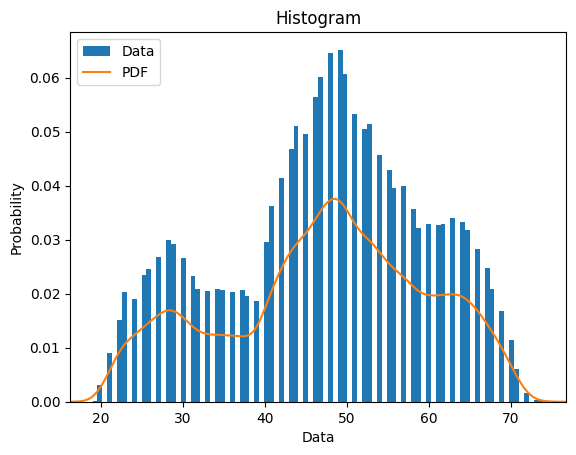

In [24]:
import scipy.stats as st

plt.hist(x, density=True, bins=bins, label="Data")
mn, mx = plt.xlim()
plt.xlim(mn, mx)
kde_xs = np.linspace(mn, mx, 300)
kde = st.gaussian_kde(x)
plt.plot(kde_xs, kde.pdf(kde_xs), label="PDF")
plt.legend(loc="upper left")
plt.ylabel("Probability")
plt.xlabel("Data")
plt.title("Histogram")

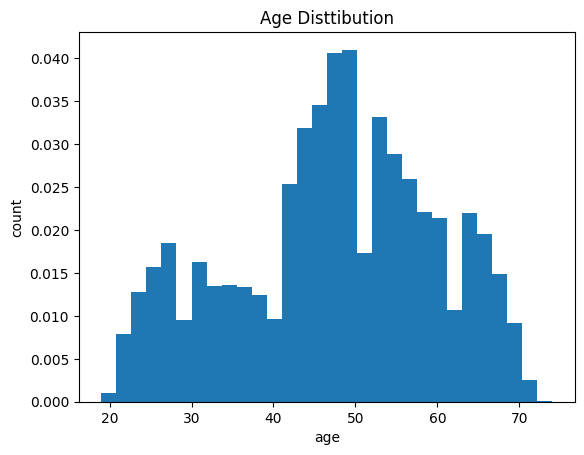

In [21]:
import matplotlib.pyplot as plt
plt.hist(ages, density=True, bins=30)
plt.title('Age Disttibution')
plt.xlabel('age')
plt.ylabel('count')
plt.show()

## All eye diseases

In [24]:
import pandas as pd
import time_distance.src.nako as nako
import matplotlib.pyplot as plt
from itertools import cycle
import matplotlib as mpl

import seaborn as sns
colors = sns.color_palette('pastel', 10)
colors = cycle([mpl.colors.rgb2hex(c) for c in colors])

ModuleNotFoundError: No module named 'time_distance'

In [13]:
LABELS_FILE = 'NAKO-590_export_baseline.csv'
LABELS_DIR = '/gpfs01/berens/data/data/NAKO/nako_decrypted/labels/NAKO-590_22032024'
image_types_ab = ['rt_leftcent', 'rt_leftnasal', 'rt_rightcent', 'rt_rightnasal']


In [14]:
date_conv = lambda x: pd.to_datetime(x, format='%Y-%m-%d')
date_cols = ['{}_{}_date'.format(image_type, j) for image_type in image_types_ab for j in range(1,4)]
df_labels = pd.read_csv(os.path.join(LABELS_DIR, LABELS_FILE), index_col='ID', sep=';', converters=dict.fromkeys(date_cols, date_conv), encoding='latin1')


In [15]:
df_labels.head()

,tgr_nako,tgr_nako_df100k,basis_sex,basis_age,basis_ageclass,basis_lvl,a_ethn1,a_ethn2,a_ses_mig_status,a_ses_aussiedler,...,d_rtbf_lve_dia_calch,d_rtbf_lve_ghost,d_rtbf_lve_hemo_pvdi,d_rtbf_lve_hemo_pvsp,d_rtbf_lve_hpig_pv,d_rtbf_lve_vasc_shun,d_rtbf_lve_vasc_fibr,d_rtbf_lve_vasc_malf,unt365_status,basis_uort
ID,,,,,,,,,,,,,,,,,,,,,
100000,1,2,2,61,60,2,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81
100001,1,1,2,53,50,2,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,811
100002,1,2,1,42,40,2,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,12
100003,1,2,1,34,30,2,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,33
100004,1,2,2,41,40,2,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,23


In [38]:
df_labels.shape

(48460, 547)

In [25]:
decoder = nako.FeatureDecoder(os.path.join(nako.LABELS_DIR, nako.METADATA_FILE))


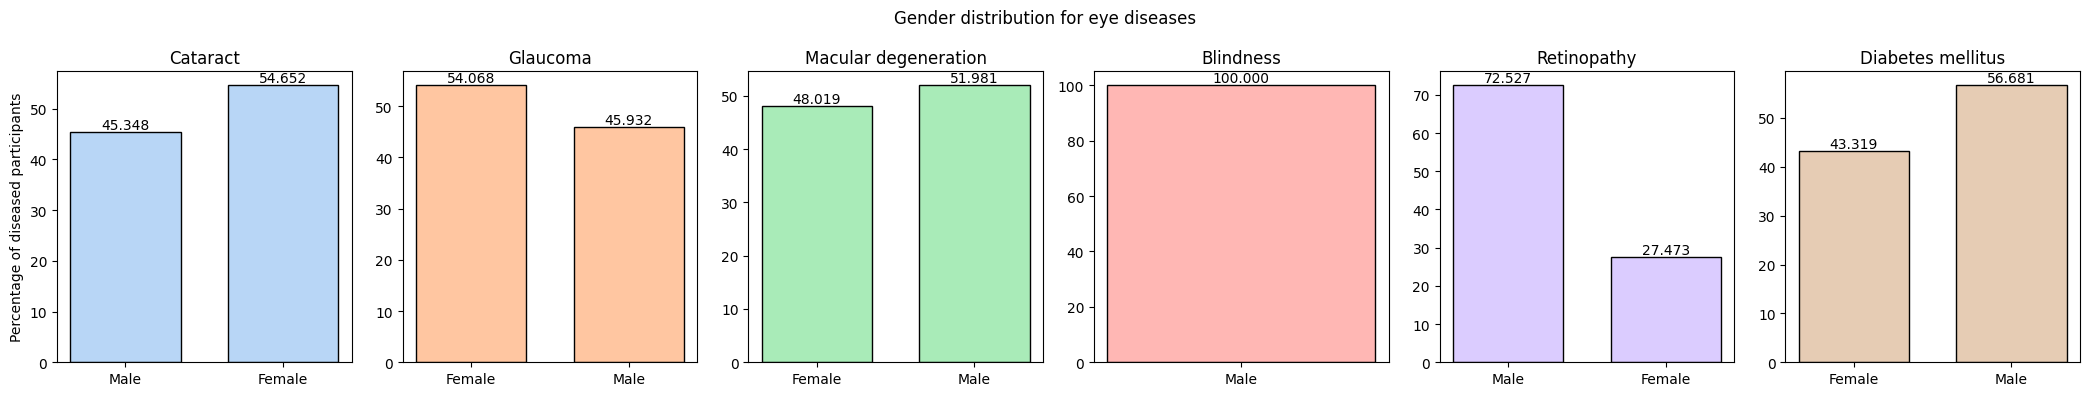

In [30]:
feature_names = ['basis_sex', 'd_an_aug_1', 'd_an_aug_2', 'd_an_aug_3', 'd_an_metdm2c_2', 'd_an_metdm2c_1','d_an_met_1']
df = df_labels[feature_names].copy()

feature_name = feature_names[0]
mapping, label = decoder.decode(feature_name)
df, mapping = decoder.group_nans(feature_name, mapping, df)
df[feature_name] = df[feature_name].map(mapping)

fig, ax = plt.subplots(1, 6, figsize=(21, 4))

for i, feature_name in enumerate(feature_names[1:]):
    mapping, label = decoder.decode(feature_name)
    df, mapping = decoder.group_nans(feature_name, mapping, df)
    df[feature_name] = df[feature_name].map(mapping)

    df_filtered = df[df[feature_name] == 'Yes']
    sns.histplot(x='basis_sex', data=df_filtered, stat='percent', shrink=0.7, color=next(colors), ax=ax[i])

    ax[i].bar_label(ax[i].containers[0], fmt='%.3f')
    ax[i].set_title(label.capitalize())
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    
ax[0].set_ylabel('Percentage of diseased participants')
fig.suptitle('Gender distribution for eye diseases')
plt.tight_layout()

In [32]:
df.head()

,basis_sex,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1
ID,,,,,,,
100000,Female,No,No,No,Missing,Missing,No
100001,Female,No,No,No,Missing,Missing,No
100002,Male,No,No,No,Missing,Missing,No
100003,Male,No,No,No,Missing,Missing,No
100004,Female,No,No,No,Missing,Missing,No


In [33]:
all_data = df.reset_index()
all_data.head()

,ID,basis_sex,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1
0,100000,Female,No,No,No,Missing,Missing,No
1,100001,Female,No,No,No,Missing,Missing,No
2,100002,Male,No,No,No,Missing,Missing,No
3,100003,Male,No,No,No,Missing,Missing,No
4,100004,Female,No,No,No,Missing,Missing,No


In [37]:
all_data.shape

(48460, 8)

In [39]:
diseased_eyes = all_data[all_data.apply(lambda r: r.str.contains('Yes').any(), axis=1)]
print(diseased_eyes.shape)
diseased_eyes.head()

(5102, 8)


,ID,basis_sex,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1
49,100049,Female,No,No,No,No,No,Yes
69,100069,Male,No,No,No,No,No,Yes
82,100082,Male,Yes,No,No,Missing,Missing,No
91,100091,Female,No,Yes,No,Missing,Missing,No
94,100094,Female,Yes,No,No,Missing,Missing,No


In [41]:
diseased_eyes['ID'].value_counts()

ID
148459    1
100049    1
100069    1
100082    1
100091    1
         ..
100187    1
100190    1
100193    1
100201    1
100204    1
Name: count, Length: 5102, dtype: int64

This implies 5102 people have a kind of eye disease

In [43]:
len(dataset_train_all)

153134

In [44]:
pwd

'/gpfs01/berens/user/inwabufo/time_distance/time_distance/t_cross_long'

In [ ]:
ls ../datasets/NAKO/

Nutzungsvertrag/


In [47]:
diseased_eyes.to_csv('../datasets/NAKO/diseased_eyes.csv', index = False)

In [ ]:
# all_age = []
# for i in range(len(dataset_train_all)):
#     img, label = dataset_train_all[i]
#     ages = label[0]
#     all_age.append(ages)

In [3]:
dataset_name = 'areds'
img_size = 512
batch_size = 64

In [4]:
root = '/gpfs01/berens/user/inwabufo/time_distance/time_distance/datasets'
image_folder = f'{root}/AREDS_macula'
train_ssl=pd.read_pickle(f'{root}/AREDS_macula_metadata/train_ssl.pkl')
vanilla_train = pd.read_pickle(f'{root}/AREDS_macula_metadata/train_vanilla.pkl')
test = pd.read_pickle(f'{root}/AREDS_macula_metadata/test.pkl')
val = pd.read_pickle(f'{root}/AREDS_macula_metadata/val.pkl')

In [5]:
all_df = pd.concat([ vanilla_train, test, val], ignore_index=True)
all_df['diagnosis_amd_grade'].describe()

count     133293
unique        12
top            1
freq       47520
Name: diagnosis_amd_grade, dtype: int64

In [7]:
unique_labels_list = list(set(all_df['diagnosis_amd_grade'].values))
print(f'Unique labels: {unique_labels_list}')
n_unique_labels = len(unique_labels_list)
print(f'Number of unique labels: {n_unique_labels}')

Unique labels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Number of unique labels: 12


## Check number of classes in dataloader

In [5]:
from time_distance.src.load_data import LoadData

In [6]:
data = LoadData(dataset_str = 'areds', 
                    image_size = 224, 
                    batch_size = 512, 
                    augment_train = None,
                    return_loader=False,
                    ssl_method = 'mae',
                    return_all = 'img_lbl'
                    )
dataset_train, dataset_test, dataset_val, transforms_ = data.load()

len of directory 5023 train shape (92582, 38) val shape (8188, 38) test shape (32523, 38)


In [13]:
all_data = [dataset_train, dataset_test, dataset_val]
datasets = []
for i in range(3):
    datasets.append(all_data[i])

In [10]:
len(dataset_train[0])

2

In [ ]:
all_labesls = []
for data in datasets:
    for img, label in data:
        all_labesls.append(label)

all_labels = torch.stack(all_labesls, dim=0)
print(all_labels.shape)


In [ ]:
unique_labels = set(all_labels.numpy().tolist())
n_unique_labels = len(unique_labels)
print(f'Number of unique labels: {n_unique_labels}')

In [ ]:


concat_dataset = torch.utils.data.ConcatDataset(datasets)

loader = torch.utils.data.DataLoader(
    concat_dataset,
    batch_size=batch_size,
    num_workers=1,
    shuffle=False
)

print(f"Total number of samples in the concatenated dataset: {len(concat_dataset)}")
print(f"Number of samples in the training dataset: {len(dataset_train)}")
print(f"Number of samples in the test dataset: {len(dataset_test)}")
print(f"Number of samples in the validation dataset: {len(dataset_val)}")

## Check that sampling works well

In [ ]:
train_ssl.head()

In [7]:
train_ssl['len_images'].describe()

count    6170.000000
mean       15.005186
std         6.177913
min         1.000000
25%        10.000000
50%        16.000000
75%        20.000000
max        42.000000
Name: len_images, dtype: float64

In [8]:
vanilla_train.columns

Index(['patient_id', 'eye_id', 'original_image_name', 'original_img_size',
       'new_image_name', 'new_image_size', 'KeyError', 'Gradable',
       'Confidence', 'patient_idright', 'image_file', 'patient_idleft',
       'image_id', 'visit_number', 'image_eye', 'image_field', 'image_side',
       'image_path', 'diagnosis_amd_grade', 'diagnosis_amd_grade_other_eye',
       'clinical_smoking_status', 'clinical_bmi_status',
       'clinical_diabetes_status', 'patient_sex',
       'clinical_high_blood_pressure_baseline',
       'clinical_visual_acuity_baseline_right',
       'clinical_visual_acuity_baseline_left', 'clinical_treatment_category',
       'clinical_laser_photocoagulation_right',
       'clinical_laser_photocoagulation_left', 'diagnosis_final_amd_status',
       'clinical_centrum_intake', 'patient_age', 'equal', 'index',
       'converters', 'first_visit', 'len_images'],
      dtype='object')

In [9]:
import random

In [10]:
def sampling_methods(sampling_method, index_array):
    if sampling_method == 'rand_':
        input_array = random.sample(index_array, 2)
        random.shuffle(input_array)
        
    elif sampling_method == 'cons':
        index1 = int(np.random.randint(0,len(index_array)-1, 1))
        index2 = index1+1
        input_array = [index1, index2]
        
    elif sampling_method =='cons_rand':
        index1 = int(np.random.randint(0,len(index_array)-1, 1))
        index2 = index1+1
        input_array = [index1, index2]
        random.shuffle(input_array)
    elif sampling_method == 'anchor':
        index1 = index_array[0]
        index2 = np.random.randint(1, len(index_array))
        input_array = [index1,  index2]
    elif sampling_method == 'uniform':
        input_array = np.random.randint(0, len(index_array), 2)
    elif sampling_method == 'exponent':
        # temporal augmentation technique by https://arxiv.org/pdf/2008.03800
        scale=0.5
        
       
        T = max(index_array) + 1  
        start1 = random.choice(index_array)

        # sample a temporal gap t (bias toward small t) ---
        def sample_temporal_gap(T, scale):
            # Exponential distribution: small gaps likely, large gaps are rare
            t = random.expovariate(1.0 / (scale * (T - 1)))
            t = min(t, T - 1)
            return int(round(t))

        # Keep sampling a gap until it's valid for this start index
        max_tries = 10
        for _ in range(max_tries):
            t = sample_temporal_gap(T, scale)
            start2 = start1 + t
            if start2 in index_array:
                break
        else:
            # Fallback: random different index
            remaining = [i for i in index_array if i != start1]
            start2 = random.choice(remaining)

        return [start1, start2]

    else:
        raise ValueError (f'Invalid input {sampling_method}. \
            Specify how you want the positives: consecutive (cons), \
            random (rand) or consecutive random (cons_rand), anchor')
    return input_array

In [15]:
class AREDSContrastiveDataset(Dataset):
    def __init__(
        self,
        image_dir: str,
        metadata_df: pd.DataFrame,
        transform = None,
        sampler:str = "cons",
        return_all: bool = False,
        model = 'simclr',
        prefix = 'C_',
        **kwargs
    ) -> None:

        self.image_dir = image_dir
        self.metadata_df = metadata_df
        self.sampler = sampler
        self.return_all = return_all
        self.transform = transform
        self.model = model
        self.prefix = prefix
        # print(self.metadata_df.head(2))

    def __len__(self):
        return len(self.metadata_df)
    
    def __getitem__(self, idx):     
        # print(f"Getting item {idx} from {self.metadata_df.shape[0]} items")
        id = self.metadata_df.iloc[idx]['eye_id']
        labels = self.metadata_df.iloc[idx]['diagnosis_amd_grade']
        index_list = self.metadata_df.iloc[idx]['image_path']
        patient_age = self.metadata_df.iloc[idx]['patient_age']
        #patient_sex = 
        index_array = list(range(len(index_list)))
        seq_len = len(index_array)
        if seq_len < 2:
            index_list = [index_list[0], index_list[0]]
            index_array = list(range(len(index_list)))


        input_array = sampling_methods(self.sampler, index_array)
        # print(f"you are using indices {input_array} from {index_array}")
        images_ = []
        labels_ = []
        patient_age_list = []
        for j in input_array:
            print(f"Getting image {j} from {input_array} with index {index_array}")
            img_filename = os.path.join(self.image_dir,  f"{self.prefix}{index_list[j]}")
            print(f"Image filename: {img_filename}")
            labels_.append(labels[j])
            patient_age_list.append(patient_age[j])
            x = Image.open(img_filename).convert("RGB")

            if self.transform:
                x = self.transform(x)

            images_.append(x)
             
        view1 = images_[0]
        view2 = images_[1]        
        if self.return_all is True:
            if self.model == 'vicreg':
                return view1, view2,  id, patient_age_list[0], patient_age_list[1]
            elif self.model == 'tsimcne':
                return (view1, view2)
            elif self.model == 'preti':
                return torch.stack([view1, view2], dim=0)
            else:
                return view1, view2, id, patient_age_list[0], patient_age_list[1], seq_len
        else:
            
            return view1, view2

In [25]:
dataset_train = AREDSContrastiveDataset(image_folder, train_ssl, transform=None, sampler = 'cons', model='preti')
dataset_train[0]

Getting image 2 from [2, 3] with index [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Image filename: /gpfs01/berens/user/inwabufo/time_distance/time_distance/datasets/AREDS_macula/C_59931/59931_06_F2_LE_LS.jpg
Getting image 3 from [2, 3] with index [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Image filename: /gpfs01/berens/user/inwabufo/time_distance/time_distance/datasets/AREDS_macula/C_59931/59931_06_F2_LE_RS.jpg


/tmp/ipykernel_1730972/1964441980.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  index1 = int(np.random.randint(0,len(index_array)-1, 1))


(<PIL.Image.Image image mode=RGB size=198x198>,
 <PIL.Image.Image image mode=RGB size=198x198>)

## Get Data Stats

In [33]:
class AREDSDatasetStas(Dataset):
    def __init__(
        self,
        image_dir: str,
        metadata_df: pd.DataFrame,
        root: str = "",
        transform= None,
        prefix = 'C_',
    ) -> None:

        self.image_dir = image_dir
        self.metadata_df = metadata_df
        self.transform = transform
        self.root = root
        self.prefix = prefix
       
        
    def __getitem__(self, idx: int):
        row= self.metadata_df.iloc[idx]
        
        patient_id = row["eye_id"]
        label =  row["diagnosis_amd_grade"]
        image_path = str(row["image_path"])

        
        img_filename = os.path.join(self.image_dir, f"{self.prefix}{image_path}")
        image = Image.open(img_filename).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return self.metadata_df.shape[0]

In [34]:
root = '/gpfs01/berens/user/inwabufo/time_distance/time_distance/datasets'
image_folder = f'{root}/AREDS_macula'
train_ssl=pd.read_pickle(f'{root}/AREDS_macula_metadata/train_ssl.pkl')
vanilla_train = pd.read_pickle(f'{root}/AREDS_macula_metadata/train_vanilla.pkl')
test = pd.read_pickle(f'{root}/AREDS_macula_metadata/test.pkl')
val = pd.read_pickle(f'{root}/AREDS_macula_metadata/val.pkl')

In [35]:
transforms_ = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])

In [36]:
dataset_train = AREDSDatasetStas(image_folder, vanilla_train, transform=transforms_)
dataset_test = AREDSDatasetStas(image_folder, test, transform=transforms_)
dataset_val = AREDSDatasetStas(image_folder, val, transform=transforms_)

In [ ]:
all_data = [dataset_train, dataset_test, dataset_val]
datasets = []
for i in range(3):
    datasets.append(all_data[i])

concat_dataset = torch.utils.data.ConcatDataset(datasets)

loader = torch.utils.data.DataLoader(
    concat_dataset,
    batch_size=batch_size,
    num_workers=1,
    shuffle=False
)

print(f"Total number of samples in the concatenated dataset: {len(concat_dataset)}")
print(f"Number of samples in the training dataset: {len(dataset_train)}")
print(f"Number of samples in the test dataset: {len(dataset_test)}")
print(f"Number of samples in the validation dataset: {len(dataset_val)}")

In [ ]:
mean = 0.
std = 0.
nb_samples = 0.
for data, label in loader:
    batch_samples = data.size(0)
    data = data.view(batch_samples, data.size(1), -1)
    mean += data.mean(2).sum(0)
    std += data.std(2).sum(0)
    nb_samples += batch_samples

mean /= nb_samples
std /= nb_samples
